### **Dataset1: 初婚年齡 (URL CSV)**

##### **Data Load**

In [2]:
import requests
import urllib3
from io import StringIO
import pandas as pd

urls_first_marriage = {
    110:"https://opdadm.moi.gov.tw/api/v1/no-auth/resource/api/dataset/8736F690-4B8E-43FE-8CFE-1335109BB3D4/resource/91F53D99-29E3-490B-A3D1-1ABA8CCA3F12/download",
    111:"https://opdadm.moi.gov.tw/api/v1/no-auth/resource/api/dataset/8736F690-4B8E-43FE-8CFE-1335109BB3D4/resource/4BA7A267-7DB0-41C4-874B-14BB805CEAC0/download",
    112:"https://opdadm.moi.gov.tw/api/v1/no-auth/resource/api/dataset/8736F690-4B8E-43FE-8CFE-1335109BB3D4/resource/520552FC-4852-48D4-BE26-7FC6665E1EA8/download",
    113:"https://opdadm.moi.gov.tw/api/v1/no-auth/resource/api/dataset/8736F690-4B8E-43FE-8CFE-1335109BB3D4/resource/FCB64662-383B-41DB-9387-A02624F74EAA/download"
}

dfs = []

for year, url in urls_first_marriage.items():
    response = requests.get(url, verify=False)
    df = pd.read_csv(StringIO(response.text))
    dfs.append(df)

df_first_marriage_org = pd.concat(dfs, ignore_index=True)

# Since SSL certificates for some government data portals may be missing or invalid, suppress the InsecureRequestWarning for this personal project.
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

print(df_first_marriage_org)

     統計年     按照別    行政區域代碼  區域別 性別  平均歲數
0    110  按發生日期分  65000000  新北市  男  33.0
1    110  按發生日期分  65000000  新北市  女  31.1
2    110  按發生日期分  63000000  臺北市  男  33.9
3    110  按發生日期分  63000000  臺北市  女  32.3
4    110  按發生日期分  68000000  桃園市  男  31.9
..   ...     ...       ...  ... ..   ...
171  112  按發生日期分  10020000  嘉義市  女  31.0
172  112  按發生日期分   9020000  金門縣  男  32.6
173  112  按發生日期分   9020000  金門縣  女  30.6
174  112  按發生日期分   9007000  連江縣  男  33.1
175  112  按發生日期分   9007000  連江縣  女  32.0

[176 rows x 6 columns]


In [3]:
print(df_first_marriage_org['按照別'].unique())
print(df_first_marriage_org['統計年'].unique())

<StringArray>
['按發生日期分']
Length: 1, dtype: str
[110 111 112]


##### **Data Transformation**

In [4]:
# make a copy before renaming
df_first_marriage_copy = df_first_marriage_org

# rename columns
df_first_marriage_org.rename(columns = {
    "統計年":"mingo_year",
    "區域別":"city",
    "性別":"gender",
    "平均歲數":"age"
}, inplace = True)

# drop unnecessary columns
df_first_marriage = df_first_marriage_org.drop(columns = ["按照別", "行政區域代碼"])

# Convert mingo_year
df_first_marriage['year'] = df_first_marriage['mingo_year'] + 1911
df_first_marriage = df_first_marriage.drop(columns = "mingo_year")

# reorder columns
df_first_marriage = df_first_marriage[['year', 'city', 'gender', 'age']]

print(df_first_marriage)
print(df_first_marriage.dtypes)

     year city gender   age
0    2021  新北市      男  33.0
1    2021  新北市      女  31.1
2    2021  臺北市      男  33.9
3    2021  臺北市      女  32.3
4    2021  桃園市      男  31.9
..    ...  ...    ...   ...
171  2023  嘉義市      女  31.0
172  2023  金門縣      男  32.6
173  2023  金門縣      女  30.6
174  2023  連江縣      男  33.1
175  2023  連江縣      女  32.0

[176 rows x 4 columns]
year        int64
city          str
gender        str
age       float64
dtype: object


##### **Data Exploration**

In [5]:
print(df_first_marriage['year'].unique())
print(df_first_marriage['city'].unique())
print(df_first_marriage['gender'].unique())

[2021 2022 2023]
<StringArray>
['新北市', '臺北市', '桃園市', '臺中市', '臺南市', '高雄市', '宜蘭縣', '新竹縣', '苗栗縣', '彰化縣', '南投縣',
 '雲林縣', '嘉義縣', '屏東縣', '臺東縣', '花蓮縣', '澎湖縣', '基隆市', '新竹市', '嘉義市', '金門縣', '連江縣']
Length: 22, dtype: str
<StringArray>
['男', '女']
Length: 2, dtype: str


In [6]:
# Check missing values in each column
print(df_first_marriage.isna().sum())

# Calculate multiple statistics at once
df_first_marriage_statistics = df_first_marriage.groupby('year').agg(
    row_count = ("age", "size"),
    max_age = ("age", "max"),
    min_age = ("age", "min"),
    avg_age = ("age", "mean")
).reset_index()
df_first_marriage_statistics['avg_age'] = df_first_marriage_statistics['avg_age'].round(2)
print(df_first_marriage_statistics)

year      0
city      0
gender    0
age       0
dtype: int64
   year  row_count  max_age  min_age  avg_age
0  2021         44     33.9     29.1    30.94
1  2022         44     34.1     29.2    31.11
2  2023         88     34.4     29.4    31.54


In [7]:
df_first_marriage_counts = (
    df_first_marriage
    .groupby(['year', 'city', 'gender', 'age'])
    .size()
    .reset_index(name = 'count')
)

print('Has duplicates:')
print(df_first_marriage_counts[df_first_marriage_counts['count'] != 1].reset_index(drop = True))

Has duplicates:
    year city gender   age  count
0   2023  南投縣      女  30.0      2
1   2023  南投縣      男  32.2      2
2   2023  嘉義市      女  31.0      2
3   2023  嘉義市      男  32.7      2
4   2023  嘉義縣      女  29.6      2
5   2023  嘉義縣      男  32.1      2
6   2023  基隆市      女  30.8      2
7   2023  基隆市      男  32.8      2
8   2023  宜蘭縣      女  30.1      2
9   2023  宜蘭縣      男  32.1      2
10  2023  屏東縣      女  29.4      2
11  2023  屏東縣      男  31.9      2
12  2023  彰化縣      女  29.8      2
13  2023  彰化縣      男  31.7      2
14  2023  新北市      女  31.8      2
15  2023  新北市      男  33.7      2
16  2023  新竹市      女  30.9      2
17  2023  新竹市      男  32.9      2
18  2023  新竹縣      女  30.4      2
19  2023  新竹縣      男  32.4      2
20  2023  桃園市      女  30.6      2
21  2023  桃園市      男  32.6      2
22  2023  澎湖縣      女  30.3      2
23  2023  澎湖縣      男  31.9      2
24  2023  臺中市      女  30.6      2
25  2023  臺中市      男  32.5      2
26  2023  臺北市      女  32.6      2
27  2023  臺北市      男  34.4      

In [8]:
# Check impossible age values
print(df_first_marriage[df_first_marriage['age'] < 0])
print(df_first_marriage[df_first_marriage['age'] > 120])

Empty DataFrame
Columns: [year, city, gender, age]
Index: []
Empty DataFrame
Columns: [year, city, gender, age]
Index: []


##### **Data Cleaning**

In [9]:
# 2023 seems to have twice as many records as the previous two years.
# Assuming each combination of year, city, and gender should have only one record, this indicates possible duplicate entries that need to be checked.
df_first_marriage_clean = df_first_marriage.drop_duplicates(
    subset = ['year', 'city', 'gender', 'age'],
    keep = "first"
)
print(df_first_marriage_clean)

# Check statistics again
df_first_marriage_statistics_check = df_first_marriage_clean.groupby('year').agg(
    row_count = ("age", "size"),
    max_age = ("age", "max"),
    min_age = ("age", "min"),
    avg_age = ("age", "mean")
).reset_index()
df_first_marriage_statistics_check['avg_age'] = df_first_marriage_statistics_check['avg_age'].round(2)
print(df_first_marriage_statistics_check)

     year city gender   age
0    2021  新北市      男  33.0
1    2021  新北市      女  31.1
2    2021  臺北市      男  33.9
3    2021  臺北市      女  32.3
4    2021  桃園市      男  31.9
..    ...  ...    ...   ...
127  2023  嘉義市      女  31.0
128  2023  金門縣      男  32.6
129  2023  金門縣      女  30.6
130  2023  連江縣      男  33.1
131  2023  連江縣      女  32.0

[132 rows x 4 columns]
   year  row_count  max_age  min_age  avg_age
0  2021         44     33.9     29.1    30.94
1  2022         44     34.1     29.2    31.11
2  2023         44     34.4     29.4    31.54


##### **Data Analysis - Average first marriage age**

In [10]:
# Use df_first_marriage_clean from now on
# Overall gender trend
df_first_marriage_trend = (
    df_first_marriage_clean
    .groupby(['year', 'gender'])['age']
    .mean()
    .reset_index(name = 'avg_age')
    .sort_values(by = ['gender', 'year'], ascending = [False, True])
    .reset_index(drop = True)
)
df_first_marriage_trend['avg_age'] = df_first_marriage_trend['avg_age'].round(2)

print('First Marriage Age Gender Trend:')
print(df_first_marriage_trend)

First Marriage Age Gender Trend:
   year gender  avg_age
0  2021      男    31.90
1  2022      男    32.05
2  2023      男    32.54
3  2021      女    29.99
4  2022      女    30.17
5  2023      女    30.54


In [11]:
# Major city trend
major_cities = ['新北市', '臺北市', '桃園市', '臺中市', '臺南市', '高雄市']

# Major - Male
df_first_marriage_major_male = (
    df_first_marriage_clean[
        (df_first_marriage_clean['city'].isin(major_cities)) &
        (df_first_marriage_clean['gender'] == '男')
        ]
        .sort_values(by=['city', 'year'], ascending=[True, True])
        .reset_index(drop = True)
)

df_first_marriage_major_male = df_first_marriage_major_male.drop(columns = 'gender')
print('Major City')
print('Male:')
print(df_first_marriage_major_male)

# Major - female
df_first_marriage_major_female = (
    df_first_marriage_clean[
        (df_first_marriage_clean['city'].isin(major_cities)) &
        (df_first_marriage_clean['gender'] == '女')
        ]
        .sort_values(by=['city', 'year'], ascending=[True, True])
        .reset_index(drop = True)
)

df_first_marriage_major_female = df_first_marriage_major_female.drop(columns = 'gender')
print('')
print('Female:')
print(df_first_marriage_major_female)

Major City
Male:
    year city   age
0   2021  新北市  33.0
1   2022  新北市  33.3
2   2023  新北市  33.7
3   2021  桃園市  31.9
4   2022  桃園市  32.3
5   2023  桃園市  32.6
6   2021  臺中市  32.0
7   2022  臺中市  32.3
8   2023  臺中市  32.5
9   2021  臺北市  33.9
10  2022  臺北市  34.1
11  2023  臺北市  34.4
12  2021  臺南市  32.5
13  2022  臺南市  32.7
14  2023  臺南市  32.9
15  2021  高雄市  32.5
16  2022  高雄市  32.8
17  2023  高雄市  33.0

Female:
    year city   age
0   2021  新北市  31.1
1   2022  新北市  31.3
2   2023  新北市  31.8
3   2021  桃園市  30.0
4   2022  桃園市  30.4
5   2023  桃園市  30.6
6   2021  臺中市  30.2
7   2022  臺中市  30.5
8   2023  臺中市  30.6
9   2021  臺北市  32.3
10  2022  臺北市  32.3
11  2023  臺北市  32.6
12  2021  臺南市  30.5
13  2022  臺南市  30.7
14  2023  臺南市  30.9
15  2021  高雄市  30.5
16  2022  高雄市  30.9
17  2023  高雄市  31.0


In [12]:
# Non-major city trend
# Male
df_first_marriage_nonmajor_male = (
    df_first_marriage_clean[
        (~df_first_marriage_clean['city'].isin(major_cities)) &
        (df_first_marriage_clean['gender'] == '男')
        ]
        .sort_values(by=['city', 'year'], ascending=[True, True])
        .reset_index(drop = True)
)

df_first_marriage_nonmajor_male = df_first_marriage_nonmajor_male.drop(columns = 'gender')

# Female
df_first_marriage_nonmajor_female = (
    df_first_marriage_clean[
        (~df_first_marriage_clean['city'].isin(major_cities)) &
        (df_first_marriage_clean['gender'] == '女')
        ]
        .sort_values(by=['city', 'year'], ascending=[True, True])
        .reset_index(drop = True)
)

df_first_marriage_nonmajor_female = df_first_marriage_nonmajor_female.drop(columns = 'gender')

In [13]:
# Major cities vs Non-major cities
# Male
major_male = (
    df_first_marriage_major_male
    .groupby('year')['age']
    .mean()
    .reset_index(name = 'avg_age')
)
major_male['avg_age'] = major_male['avg_age'].round(2)

print('Male trend')
print('Major city:')
print(major_male)

nonmajor_male = (
    df_first_marriage_nonmajor_male
    .groupby('year')['age']
    .mean()
    .reset_index(name = 'avg_age')
)
nonmajor_male['avg_age'] = nonmajor_male['avg_age'].round(2)

print('')
print('Non-major city:')
print(nonmajor_male)

# Female
major_female = (
    df_first_marriage_major_female
    .groupby('year')['age']
    .mean()
    .reset_index(name = 'avg_age')
)
major_female['avg_age'] = major_female['avg_age'].round(2)

print('')
print('Female trend')
print('Major city:')
print(major_female)

nonmajor_female = (
    df_first_marriage_nonmajor_female
    .groupby('year')['age']
    .mean()
    .reset_index(name = 'avg_age')
)
nonmajor_female['avg_age'] = nonmajor_female['avg_age'].round(2)

print('')
print('Non-major city:')
print(nonmajor_female)


Male trend
Major city:
   year  avg_age
0  2021    32.63
1  2022    32.92
2  2023    33.18

Non-major city:
   year  avg_age
0  2021    31.62
1  2022    31.72
2  2023    32.30

Female trend
Major city:
   year  avg_age
0  2021    30.77
1  2022    31.02
2  2023    31.25

Non-major city:
   year  avg_age
0  2021    29.70
1  2022    29.86
2  2023    30.28


In [14]:
cities_diff_male = (
    major_male[['year', 'avg_age']]
    .merge(
        nonmajor_male[['year', 'avg_age']],
        on='year',
        suffixes=('_major', '_nonmajor')
    )
    .assign(age_diff=lambda x: x['avg_age_major'] - x['avg_age_nonmajor'])
    [['year', 'age_diff']]
)

print('Major vs Non-major city')
print('Male:')
print(cities_diff_male)

cities_diff_female = (
    major_female[['year', 'avg_age']]
    .merge(
        nonmajor_female[['year', 'avg_age']],
        on='year',
        suffixes=('_major', '_nonmajor')
    )
    .assign(age_diff=lambda x: x['avg_age_major'] - x['avg_age_nonmajor'])
    [['year', 'age_diff']]
)

print('')
print('Female:')
print(cities_diff_female)

Major vs Non-major city
Male:
   year  age_diff
0  2021      1.01
1  2022      1.20
2  2023      0.88

Female:
   year  age_diff
0  2021      1.07
1  2022      1.16
2  2023      0.97


In [15]:
# City comparison (2021-2023 average)
df_first_marriage_cities_male = (
    df_first_marriage_clean[
        df_first_marriage_clean['gender'] == '男'
        ]
        .groupby('city')['age']
        .mean()
        .reset_index()
        .sort_values(by = 'age', ascending = False)
        .reset_index(drop = True)

)
df_first_marriage_cities_male['age'] = df_first_marriage_cities_male['age'].round(2)

print('Average by city')
print('Male:')
print(df_first_marriage_cities_male)

df_first_marriage_cities_female = (
    df_first_marriage_clean[
        df_first_marriage_clean['gender'] == '女'
        ]
        .groupby('city')['age']
        .mean()
        .reset_index()
        .sort_values(by = 'age', ascending = False)
        .reset_index(drop = True)
)
df_first_marriage_cities_female['age'] = df_first_marriage_cities_female['age'].round(2)

print('')
print('Female:')
print(df_first_marriage_cities_female)


Average by city
Male:
   city    age
0   臺北市  34.13
1   新北市  33.33
2   高雄市  32.77
3   臺南市  32.70
4   基隆市  32.70
5   新竹市  32.67
6   嘉義市  32.37
7   桃園市  32.27
8   臺中市  32.27
9   新竹縣  32.10
10  金門縣  32.03
11  連江縣  32.00
12  苗栗縣  31.90
13  臺東縣  31.80
14  宜蘭縣  31.77
15  花蓮縣  31.70
16  屏東縣  31.70
17  南投縣  31.57
18  嘉義縣  31.50
19  彰化縣  31.50
20  澎湖縣  31.40
21  雲林縣  31.40

Female:
   city    age
0   臺北市  32.40
1   新北市  31.40
2   高雄市  30.80
3   連江縣  30.80
4   新竹市  30.73
5   臺南市  30.70
6   基隆市  30.67
7   嘉義市  30.50
8   臺中市  30.43
9   桃園市  30.33
10  新竹縣  30.17
11  金門縣  30.10
12  苗栗縣  29.90
13  宜蘭縣  29.87
14  澎湖縣  29.77
15  臺東縣  29.73
16  花蓮縣  29.60
17  南投縣  29.57
18  彰化縣  29.57
19  屏東縣  29.43
20  嘉義縣  29.37
21  雲林縣  29.33


##### **Findings**

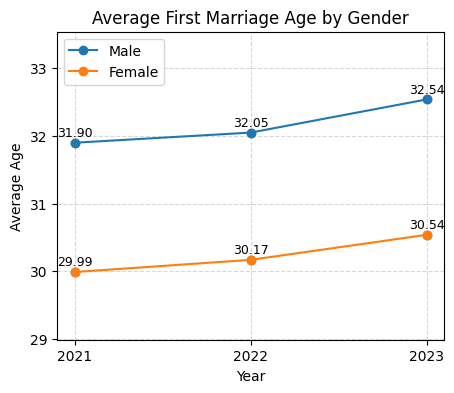

In [16]:
import matplotlib.pyplot as plt

# Pivot so each gender is a separate column
df_plot = df_first_marriage_trend.pivot(index='year', columns='gender', values='avg_age')

plt.figure(figsize=(5,4))

# Plot lines
plt.plot(df_plot.index, df_plot['男'], marker='o', label='Male')
plt.plot(df_plot.index, df_plot['女'], marker='o', label='Female')

# Add data labels for all points
for gender in df_plot.columns:
    plt.scatter(df_plot.index, df_plot[gender])  # ensures markers are on top
    for x, y in zip(df_plot.index, df_plot[gender]):
        plt.text(x, y + 0.05, f'{y:.2f}', ha='center', va='bottom', fontsize=9)

# Chart formatting
plt.title('Average First Marriage Age by Gender')
plt.xlabel('Year')
plt.ylabel('Average Age')
plt.xticks(df_plot.index)
plt.ylim(df_plot.values.min()-1, df_plot.values.max()+1)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

##### **Load into PostgreSQL**

In [17]:
# Create connection from Python to PostgreSQL
from sqlalchemy import create_engine
import os

user = os.getenv("PG_USER")
password = os.getenv("PG_PASSWORD")
host = "localhost"
port = "5432"
database = "twmarriage"
engine = create_engine(
    f"postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}"
)

In [18]:
# Load dataframe to PostgreSQL
df_first_marriage_clean.to_sql(
    "first_marriage_age",
    engine,
    if_exists = "replace",
    index = False
)

132